In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from matplotlib import pyplot
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -o "/content/drive/MyDrive/ia/archive.zip" -d "/content/HASYv2"

input_layer_size = 1024
num_labels = 369

df = pd.read_csv("/content/HASYv2/hasy-data-labels.csv")

imagenes = []
for ruta in df["path"]:
    img = Image.open("/content/HASYv2/" + ruta).convert("L")
    imagenes.append(np.array(img).flatten())

X = np.array(imagenes, dtype=np.float32)
y = df["symbol_id"].values

clases_unicas = np.unique(y)

# guardar el mapa ANTES de modificar y
mapa_clases = {}
for i, clase in enumerate(clases_unicas):
    latex = df[df["symbol_id"] == clase]["latex"].values[0]
    mapa_clases[i] = latex

# renombrar con copia limpia
y_nuevo = np.zeros_like(y)
for i, clase in enumerate(clases_unicas):
    y_nuevo[y == clase] = i
y = y_nuevo.astype(np.int64)
m = len(y)

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95012.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95013.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95014.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95015.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95016.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95017.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95018.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95019.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95020.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95021.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95022.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95023.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95024.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95025.png  
  inflating: /content/HASYv2/hasyv2/hasy-data/v2-95026.png  
  inflating: /content/HA

In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    # Calcula filas, columnas
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promocionar a una matriz bidimensional
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensinal.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Calcula el numero de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(32, 32),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

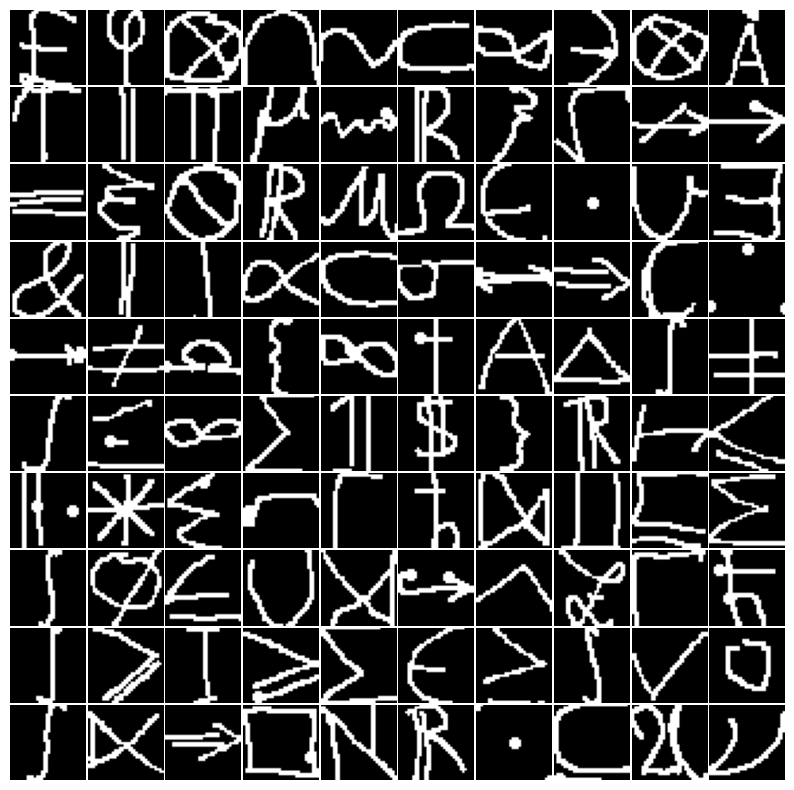

In [ ]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

In [ ]:
mu = X.mean(axis=0)
sigma = X.std(axis=0) + 1e-8  # evitar división por cero
X = (X - mu) / sigma

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
class HASYDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

train_dataset = HASYDataset(X_train, y_train)
test_dataset  = HASYDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

In [ ]:
class RedHASY(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(RedHASY, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = RedHASY(input_layer_size, 512, num_labels).to(device)

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            preds = torch.argmax(model(x_b), axis=1)
            correct += (preds == y_b).sum().item()
            total += len(y_b)
    return correct / total * 100

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
best_acc = 0
PATH = "./checkpoint_hasy.pt"

for epoch in range(1, epochs + 1):
    model.train()
    losses = []
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_b), y_b)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    val_acc = evaluate(model, test_loader)
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), PATH)
        print(f"  → Checkpoint guardado (val_acc: {val_acc:.2f}%)")

    print(f"Epoch {epoch}/{epochs}  loss: {np.mean(losses):.4f}  val_acc: {val_acc:.2f}%")

# cargar el mejor modelo
model.load_state_dict(torch.load(PATH))
print(f"\nMejor val_acc: {best_acc:.2f}%")

  → Checkpoint guardado (val_acc: 71.10%)
Epoch 1/20  loss: 1.6183  val_acc: 71.10%
  → Checkpoint guardado (val_acc: 73.11%)
Epoch 2/20  loss: 0.9062  val_acc: 73.11%
Epoch 3/20  loss: 0.7035  val_acc: 72.94%
  → Checkpoint guardado (val_acc: 73.61%)
Epoch 4/20  loss: 0.5591  val_acc: 73.61%
Epoch 5/20  loss: 0.4497  val_acc: 72.64%
Epoch 6/20  loss: 0.3618  val_acc: 72.21%
Epoch 7/20  loss: 0.2918  val_acc: 72.81%
Epoch 8/20  loss: 0.2405  val_acc: 72.25%
Epoch 9/20  loss: 0.2015  val_acc: 72.01%
Epoch 10/20  loss: 0.1768  val_acc: 71.87%
Epoch 11/20  loss: 0.1625  val_acc: 71.71%
Epoch 12/20  loss: 0.1458  val_acc: 72.54%
Epoch 13/20  loss: 0.1361  val_acc: 71.84%
Epoch 14/20  loss: 0.1250  val_acc: 71.32%
Epoch 15/20  loss: 0.1173  val_acc: 71.96%
Epoch 16/20  loss: 0.1180  val_acc: 71.72%
Epoch 17/20  loss: 0.1105  val_acc: 71.83%
Epoch 18/20  loss: 0.0981  val_acc: 71.76%
Epoch 19/20  loss: 0.0938  val_acc: 71.81%
Epoch 20/20  loss: 0.0979  val_acc: 71.03%

Mejor val_acc: 73.61%


Precisión final: 73.61%


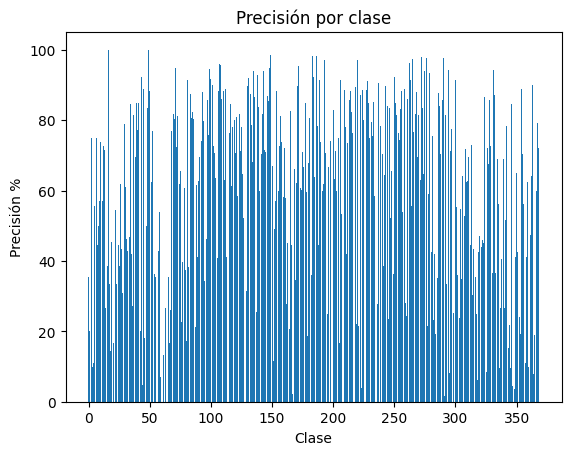

In [ ]:
# precisión global
print(f'Precisión final: {evaluate(model, test_loader):.2f}%')

# precisión por clase
precisiones = []
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for x_b, y_b in test_loader:
        preds = torch.argmax(model(x_b.to(device)), axis=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_b.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
for c in range(num_labels):
    mask = (all_true == c)
    if mask.sum() > 0:
        precisiones.append(np.mean(all_preds[mask] == all_true[mask]) * 100)
    else:
        precisiones.append(0)

pyplot.bar(np.arange(num_labels), precisiones)
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión %')
pyplot.title('Precisión por clase')
pyplot.show()

\int
\propto
\vdash
\$
\Sigma
\lambda
\varphi
\hbar
\mu
\langle
\Vdash
\fint


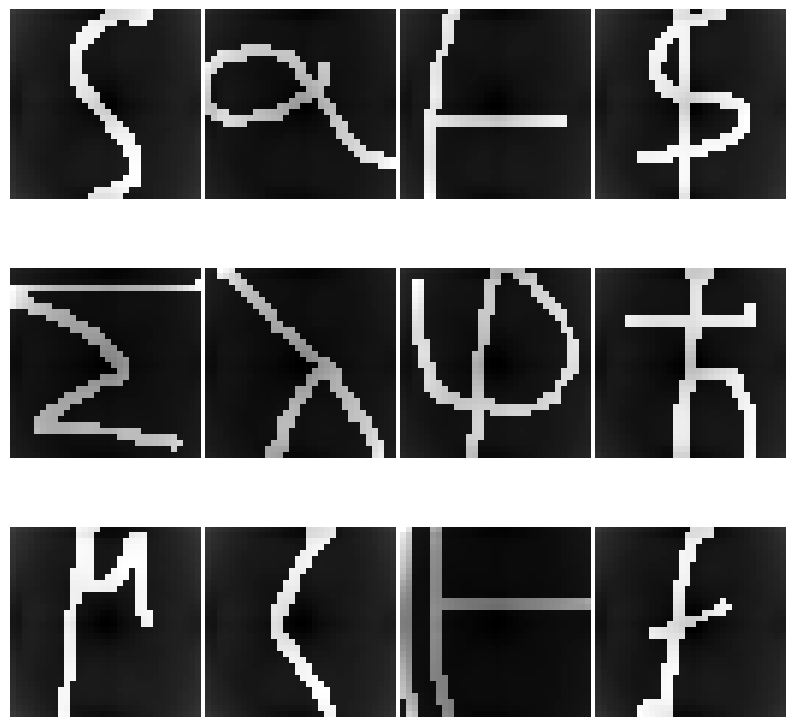

In [ ]:
# visualizar algunas predicciones
muestra_X, muestra_y = test_dataset[100:112]
with torch.no_grad():
    p = torch.argmax(model(muestra_X.to(device)), axis=1).cpu().numpy()
for c in p:
    print(mapa_clases[int(c)])
displayData(muestra_X.numpy())